In [2]:
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.lines import Line2D
import itertools
from typing import Iterable, Tuple, Dict, List, Optional

In [3]:
# ---- Pauli utilities ---------------------------------------------------------

PAULI_1Q = {
    "I": np.array([[1, 0],
                [0, 1]], dtype=complex),
    "X": np.array([[0, 1],
                [1, 0]], dtype=complex),
    "Y": np.array([[0, -1j],
                [1j, 0]], dtype=complex),
    "Z": np.array([[1, 0],
                [0, -1]], dtype=complex),
}

def kron_all(mats):
    """Kronecker product of a list of 2x2 matrices (left to right)."""
    out = np.array([[1]], dtype=complex)
    for M in mats:
        out = np.kron(out, M)
    return out

def pauli_string_to_matrix(pstr: str) -> np.ndarray:
    """
    Convert a Pauli string like 'XIZY' (qubit-0 is leftmost) to a 2^n x 2^n matrix.
    """
    pstr = pstr.strip().upper().replace(" ", "")
    if not pstr or any(ch not in PAULI_1Q for ch in pstr):
        raise ValueError(f"Invalid Pauli string: {pstr}")
    mats = [PAULI_1Q[ch] for ch in pstr]
    return kron_all(mats)

# ---- Parsing lists of Pauli strings ------------------------------------------

_COEFF_RE = re.compile(r"""
    ^\s*
    (?P<coef>
        [+-]?                # sign
        (?:\d+(\.\d*)?|\.\d+)?  # real part (optional)
        (?:[eE][+-]?\d+)?       # exponent (optional)
        (?:                    # optional imaginary part like +2.3i
            [+-]
            (?:\d+(\.\d*)?|\.\d+)
            (?:[eE][+-]?\d+)?
            i
        )?
        |                      # OR a pure imaginary like 'i' or '-i'
        [+-]?i
    )?
    \s*\*?\s*
    (?P<pstr>[IXYZ]+)\s*$
""", re.VERBOSE)

def _parse_coeff(s: str) -> complex:
    """
    Parse a coefficient like:
      '', '+', '-', '2', '-0.5', 'i', '-i', '1+2i', '-3.2-0.1i'
    Returns complex; empty or '+' -> 1.0; '-' -> -1.0.
    """
    if s is None:
        return 1.0 + 0j
    s = s.strip()

    # Handle bare signs (common in inputs like "-YYII")
    if s == "" or s == "+":
        return 1.0 + 0j
    if s == "-":
        return -1.0 + 0j

    # Normalize imaginary 'i' to Python 'j'
    # Accept 'i', '+i', '-i'
    if s.lower() == "i" or s.lower() == "+i":
        return 1j
    if s.lower() == "-i":
        return -1j

    # Replace trailing/standalone 'i' with 'j' for complex()
    s = s.replace("I", "i")           # tolerate uppercase
    s = s.replace("j", "i")           # normalize to i first
    s = re.sub(r'(?<![a-zA-Z])i\b', 'j', s)  # lone/trailing i -> j
    s = s.replace('i', 'j')           # remaining i -> j

    try:
        return complex(s)
    except Exception as e:
        raise ValueError(f"Could not parse coefficient '{s}': {e}")

def normalize_pauli_list(paulis):
    """
    Normalize user input to a list of (pstr, coeff) with consistent lengths.
    Accepts:
      - ['XIZ', '0.5*ZZI', '-i*IXX']
      - [('XIZ', 1.0), ('ZZI', 0.5), ('IXX', -1j)]
    """
    norm = []
    if len(paulis) == 0:
        return norm
    # length (number of qubits) from the first item
    if isinstance(paulis[0], tuple):
        n = len(paulis[0][0])
    else:
        # parse the first string to infer n
        m = _COEFF_RE.match(paulis[0])
        if not m:
            raise ValueError(f"Bad Pauli spec: {paulis[0]}")
        n = len(m.group("pstr"))
    for item in paulis:
        if isinstance(item, tuple):
            pstr, c = item
            pstr = pstr.strip().upper()
            if len(pstr) != n:
                raise ValueError(f"Inconsistent length: {pstr} vs expected {n}")
            norm.append((pstr, complex(c)))
        else:
            text = item.strip()
            m = _COEFF_RE.match(text)
            if not m:
                raise ValueError(f"Bad Pauli spec: {text}")
            coef = _parse_coeff(m.group("coef") or "")
            pstr = m.group("pstr").upper()
            if len(pstr) != n:
                raise ValueError(f"Inconsistent length: {pstr} vs expected {n}")
            norm.append((pstr, coef))
    return norm

def sum_of_paulis(pauli_list):
    """
    Given a list of Pauli strings (optionally with scalar coefficients),
    return the summed matrix H = sum_k c_k P_k.
    Examples of accepted entries:
      'XIZY'           (coefficient defaults to 1)
      '0.5*ZZII'
      '-i * IXXY'
      ('XIZY', 0.25)
    """
    items = normalize_pauli_list(pauli_list)
    if not items:
        return np.zeros((1, 1), dtype=complex)
    n = len(items[0][0])
    dim = 1 << n
    H = np.zeros((dim, dim), dtype=complex)
    for pstr, c in items:
        H += c * pauli_string_to_matrix(pstr)
    return H

# ---- Gray-code permutations ---------------------------------------------------

def gray_code_order(n_qubits: int):
    """
    Return a list 'perm' of length 2^n such that perm[k] is the basis index for
    the k-th Gray code word (i ^ (i >> 1)).
    """
    N = 1 << n_qubits
    return [i ^ (i >> 1) for i in range(N)]

def permute_matrix_by_order(M: np.ndarray, order: list[int]) -> np.ndarray:
    """
    Permute both rows and columns of a square matrix M according to 'order'.
    """
    M = np.asarray(M)
    if M.ndim != 2 or M.shape[0] != M.shape[1]:
        raise ValueError("M must be a square matrix.")
    if M.shape[0] != len(order):
        raise ValueError("Permutation length must match matrix size.")
    order = np.asarray(order, dtype=int)
    return M[np.ix_(order, order)]

def to_gray_code_order(M: np.ndarray) -> np.ndarray:
    """
    Convenience wrapper: infer n from dimension and permute to Gray-code order.
    """
    dim = M.shape[0]
    if dim & (dim - 1) != 0:
        raise ValueError("Dimension must be a power of 2.")
    n = int(np.log2(dim))
    return permute_matrix_by_order(M, gray_code_order(n))

def from_gray_code_order(Mg: np.ndarray) -> np.ndarray:
    """
    Inverse permutation: from Gray-code order back to the natural binary order.
    """
    dim = Mg.shape[0]
    if dim & (dim - 1) != 0:
        raise ValueError("Dimension must be a power of 2.")
    n = int(np.log2(dim))
    perm = gray_code_order(n)
    inv = np.zeros_like(perm)
    for i, p in enumerate(perm):
        inv[p] = i
    return permute_matrix_by_order(Mg, inv.tolist())

# ---- Plotting ----------------------------------------------------------------

def plot_matrix_abs(M: np.ndarray, title: str):
    """
    Plot |M| with 0 shown as white (use a reversed gray colormap).
    """
    A = np.abs(M)
    vmax = A.max() if A.size else 1.0
    plt.figure(figsize=(5.2, 4.8))
    im = plt.imshow(A, cmap="gray_r", interpolation="nearest", vmin=0.0, vmax=vmax)
    plt.colorbar(im, fraction=0.046, pad=0.04, label="|M|")
    if title:
        plt.title(title)
    plt.xlabel("column")
    plt.ylabel("row")
    plt.tight_layout()
    plt.show()

def matrix_to_fig(M, title=None, figsize=(5, 4), vmin=0.0, vmax=None, show=False):
    """
    Create a matplotlib Figure for |M| and return it.
    If show=False (default), the figure is closed so it won't auto-display.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    A = np.abs(M)
    if vmax is None:
        vmax = A.max() if A.size else 1.0

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(A, interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_xlabel("column"); ax.set_ylabel("row")
    if title:
        ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="|M|")
    fig.tight_layout()

    if not show:
        # prevents it from popping up in notebooks/interactive sessions
        import matplotlib.pyplot as plt
        plt.close(fig)

    return fig

def compose_figs_grid(figs, n_cols):
    """
    Compose a list of Figure objects into one figure with FIXED titles and
    a FIXED number of columns.

    - Titles are fixed to: "Panel 1", "Panel 2", ...
    - Columns are fixed to: 3

    Returns the composed matplotlib Figure.
    """
    import math
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

    #TITLES = [f"Panel {i+1}" for i in range(len(figs))]

    # Render each figure to an RGBA array
    imgs = []
    for fig in figs:
        canvas = FigureCanvas(fig)
        canvas.draw()
        imgs.append(np.asarray(canvas.buffer_rgba()))

    n = len(imgs)
    nrows = math.ceil(n / n_cols)
    bigfig, axes = plt.subplots(nrows, n_cols, figsize=(4 * n_cols, 4 * nrows))
    axes = np.atleast_2d(axes)

    for idx, img in enumerate(imgs):
        ax = axes.flat[idx]
        ax.imshow(img)
        #ax.set_title(TITLES[idx])
        ax.axis("off")

    # Hide any unused axes
    for idx in range(n, axes.size):
        axes.flat[idx].axis("off")

    bigfig.tight_layout()
    #return bigfig
    return

# Pauli Hamiltonains

In [4]:
def sum_pair_paulis(n, pauli1="X", pauli2="X", weight=1.):
    results = []
    for i, j in itertools.combinations(range(n), 2):
        s1 = ["I"] * n
        #s2 = ["I"] * n
        s1[i], s1[j] = pauli1, pauli2  # pauli1 on i, pauli2 on j
        #s2[i], s2[j] = pauli2, pauli1  # swapped
        results.append(str(weight) + "*" + "".join(s1))
        #results.append(str(weight) + "*" + "".join(s2))
    return results

def sum_single_paulis(n, pauli="X"):
    results = []
    for i in range(n):
        s = ["I"] * n
        s[i] = pauli
        results.append("".join(s))
    return results

def single_pauli(n, i, pauli="X"):
    results = []
    s = ["I"] * n
    s[i] = pauli
    results.append("".join(s))
    return results

def double_pauli(n, i, j, pauli1="X", pauli2="X"):
    results = []
    s = ["I"] * n
    s[i], s[j] = pauli1, pauli2
    results.append("".join(s))
    return results

def sum_NN_pair_paulis(n: int, pauli1 = "X", pauli2 = "X", coef: complex = 1.0, periodic: bool = False):
    if n < 2:
        raise ValueError("n must be >= 2")
    terms = []
    L = n - 1 + int(periodic)
    for i in range(L):
        j = (i + 1) % n
        s = ["I"] * n; s[i] = pauli1; s[j] = pauli2
        terms.append(f"{coef}" + "".join(s))
        terms.append(f"{coef}" + "".join(s))
    return terms

def make_xy_chain_paulis(n: int, coef: complex = 1.0, periodic: bool = False):
    """
    Return a list of (pstr, coef) for the n-qubit XY chain:
      H = coef * sum_{<i,j>} ( X_i X_j + Y_i Y_j )
    where <i,j> are nearest neighbors (open or periodic).
    Leftmost char = qubit 0 (MSB).
    """
    if n < 2:
        raise ValueError("n must be >= 2")
    terms = []
    L = n - 1 + int(periodic)
    for i in range(L):
        j = (i + 1) % n
        sXX = ["I"] * n; sXX[i] = "X"; sXX[j] = "X"
        sYY = ["I"] * n; sYY[i] = "Y"; sYY[j] = "Y"
        terms.append(f"{coef}" + "".join(sXX))
        terms.append(f"{coef}" + "".join(sYY))
    return terms

# Plots

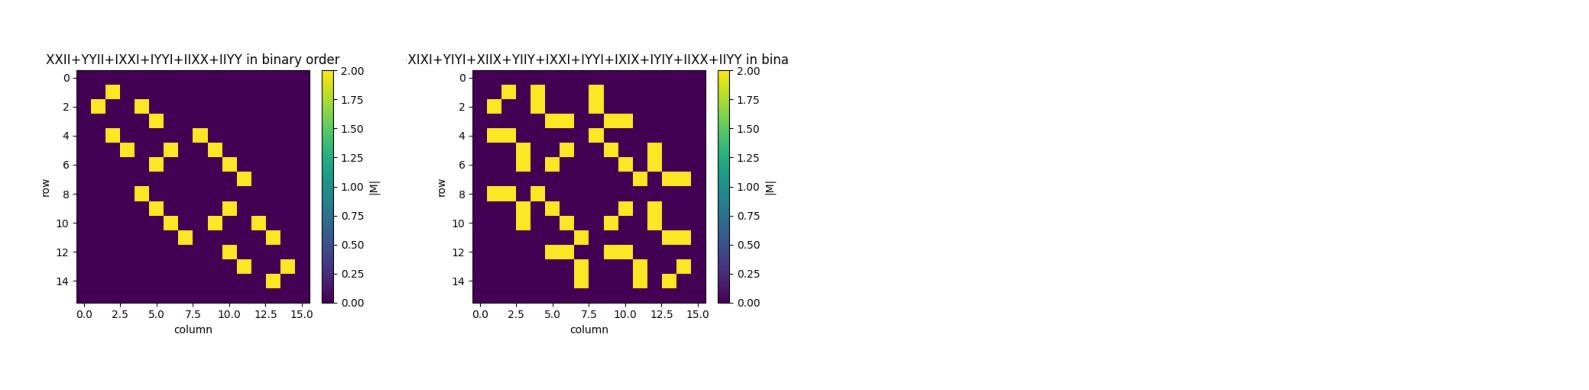

In [5]:
#PL = [["XIII"], ["IXII"], ["IIXI"], ["IIIX"], ["XIII", "IXII", "IIXI", "IIIX"]]
#PL = [["XXII"], ["XIXI"], ["XIIX"], ["IXXI"], ["IXIX"], ["IIXX","IXXI","XXII"], ["XXII","XIXI","XIIX","IXXI","IXIX","IIXX"]]
#PL = [["XXII"], ["XIXI"], ["XIIX"], ["IXXI"], ["IXIX"], ["IIXX"]]
PL = [["XXII", "YYII", "IXXI", "IYYI", "IIXX", "IIYY"], ["XXII", "YYII", "XIXI", "YIYI", "XIIX", "YIIY", "IXXI", "IYYI", "IXIX", "IYIY", "IIXX", "IIYY"]]
#PL = [["XYII", "-YXII", "IXYI", "-IYXI", "IIXY", "-IIYX"], ["XXII", "YYII", "XIXI", "YIYI", "XIIX", "YIIY", "IXXI", "IYYI", "IXIX", "IYIY", "IIXX", "IIYY"]]
figs = []
binary = True
gray = False

for P in PL:
    if binary:
        H = sum_of_paulis(P)
        FH = matrix_to_fig(H, f"{'+'.join(P)} in binary order")
        figs.append(FH)
    
    if gray:
        GH = to_gray_code_order(H)
        FGH = matrix_to_fig(GH, f"{'+'.join(P)} in gray code order")
        figs.append(FGH)

compose_figs_grid(figs, 4)

# Map to graph

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from typing import Iterable, Tuple, Dict, List, Optional, Union

# ---------- essentials ----------
def map_nodes_to_lattice(adj: np.ndarray, dims: Iterable[int]) -> Dict[int, Tuple[int, ...]]:
    if adj.ndim != 2 or adj.shape[0] != adj.shape[1]:
        raise ValueError("adj must be a square matrix")
    N = adj.shape[0]; dims = tuple(int(x) for x in dims)
    if np.prod(dims) != N: raise ValueError(f"prod(dims)={np.prod(dims)} must equal N={N}")
    return {k: tuple(np.unravel_index(k, dims, order="C")) for k in range(N)}

def edge_list_from_adj(adj: np.ndarray, directed: bool=False, tol: float=0.0) -> List[Tuple[int, int, float]]:
    if adj.ndim != 2 or adj.shape[0] != adj.shape[1]:
        raise ValueError("adj must be a square matrix")
    N = adj.shape[0]; edges: List[Tuple[int, int, float]] = []
    if directed:
        for i in range(N):
            for j in range(N):
                if i != j and abs(adj[i, j]) > tol:
                    edges.append((i, j, float(adj[i, j])))
    else:
        for i in range(N):
            for j in range(i+1, N):
                w = float(adj[i, j])
                if abs(w) > tol:
                    edges.append((i, j, w))
    return edges

# ---------- geometry helpers ----------
def _quad_bezier_patch_2d(p0, p1, bend: float, bend_sign: int=1, **patch_kwargs):
    """2D PathPatch of a quadratic Bézier from p0 to p1 with perpendicular midpoint offset."""
    x0,y0 = p0; x1,y1 = p1
    mx,my = (x0+x1)/2, (y0+y1)/2
    dx,dy = x1-x0, y1-y0
    L = (dx*dx + dy*dy)**0.5
    if L == 0:
        verts = [(x0,y0),(x0,y0),(x0,y0)]
    else:
        px,py = -dy/L, dx/L  # unit perpendicular
        cx,cy = mx + bend_sign*bend*L*px, my + bend_sign*bend*L*py
        verts = [(x0,y0),(cx,cy),(x1,y1)]
    path = Path(verts, [Path.MOVETO, Path.CURVE3, Path.CURVE3])
    return PathPatch(path, fill=False, **patch_kwargs)

def _bezier3d_samples(p0, p1, bend: float, bend_sign: int=1, n: int=60):
    """
    3D samples of a quadratic Bézier between p0 and p1 with a control point
    offset perpendicular to the segment (via cross with a fallback 'up' vector).
    """
    p0 = np.asarray(p0, float); p1 = np.asarray(p1, float)
    v  = p1 - p0
    L  = np.linalg.norm(v)
    if L == 0:
        return (np.repeat(p0[0], n), np.repeat(p0[1], n), np.repeat(p0[2], n))
    d  = v / L
    up = np.array([0.0, 0.0, 1.0])
    if abs(np.dot(d, up)) > 0.9:   # nearly parallel; choose another
        up = np.array([0.0, 1.0, 0.0])
    nvec = np.cross(d, up); nlen = np.linalg.norm(nvec)
    if nlen == 0: nvec = np.array([1.0, 0.0, 0.0])
    else: nvec /= nlen

    m  = (p0 + p1) * 0.5
    c  = m + bend_sign * bend * L * nvec  # control point
    t  = np.linspace(0.0, 1.0, n)
    one_t = 1.0 - t
    B = (one_t**2)[:,None]*p0 + (2*one_t*t)[:,None]*c + (t**2)[:,None]*p1
    return B[:,0], B[:,1], B[:,2]

# ---------- main: curved edges that RETURN (fig, ax) and suppress display by default ----------
def plot_lattice_graph_weighted_curved(adj: np.ndarray,
                                       dims: Iterable[int],
                                       node_size: float=60.0,
                                       bend: float=0.35,
                                       alt_bend: bool=True,
                                       cmap: str="coolwarm",
                                       title: Optional[str]=None,
                                       n_samples_3d: int=60,
                                       figsize: Optional[Tuple[float, float]]=None,
                                       add_colorbar: bool=True,
                                       show: bool=False,
                                       close_on_return: bool=True):
    """
    Draw a D=2 or D=3 lattice graph with curved edges (no trimming) and return (fig, ax).

    If show=False and close_on_return=True (default), the figure is *closed* before return,
    which prevents Jupyter's auto-display while still letting you do `fig.savefig(...)`.
    Set close_on_return=False if you plan to keep modifying the figure interactively.
    """
    layout = map_nodes_to_lattice(adj, dims)
    D = len(tuple(dims))
    edges = edge_list_from_adj(adj, directed=False, tol=0.0)

    weights = [w for (_,_,w) in edges]
    norm = plt.Normalize(vmin=min(weights), vmax=max(weights)) if weights else None
    cmap_obj = plt.get_cmap(cmap) if weights else None

    if D == 2:
        xs = [layout[k][1] for k in range(adj.shape[0])]
        ys = [layout[k][0] for k in range(adj.shape[0])]
        fig, ax = plt.subplots(figsize=figsize)

        for i, j, w in edges:
            p0, p1 = (xs[i], ys[i]), (xs[j], ys[j])
            sign = (1 if ((i + j) % 2 == 0) else -1) if alt_bend else 1
            color = cmap_obj(norm(w)) if norm else None
            patch = _quad_bezier_patch_2d(p0, p1, bend=bend, bend_sign=sign,
                                          edgecolor=color, linewidth=1.8, zorder=1)
            try: patch.set_capstyle("round")
            except Exception: pass
            ax.add_patch(patch)

        ax.scatter(xs, ys, s=node_size, zorder=3)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x"); ax.set_ylabel("y")
        if title: ax.set_title(title)
        if add_colorbar and norm:
            sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm); sm.set_array([])
            fig.colorbar(sm, ax=ax, label="Edge weight")
        if show:
            plt.show()
        elif close_on_return:
            # Prevent notebook auto-display
            fig.canvas.draw_idle()
            plt.close(fig)
        return fig, ax

    elif D == 3:
        from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111, projection="3d")

        xs = [layout[k][2] for k in range(adj.shape[0])]
        ys = [layout[k][1] for k in range(adj.shape[0])]
        zs = [layout[k][0] for k in range(adj.shape[0])]

        for i, j, w in edges:
            p0, p1 = (xs[i], ys[i], zs[i]), (xs[j], ys[j], zs[j])
            sign = (1 if ((i + j) % 2 == 0) else -1) if alt_bend else 1
            X, Y, Z = _bezier3d_samples(p0, p1, bend=bend, bend_sign=sign, n=n_samples_3d)
            color = cmap_obj(norm(w)) if norm else None
            ax.plot(X, Y, Z, linewidth=1.8, color=color, zorder=1)

        ax.scatter(xs, ys, zs, s=node_size, zorder=3)
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
        if title: ax.set_title(title)
        if add_colorbar and norm:
            sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm); sm.set_array([])
            fig.colorbar(sm, ax=ax, label="Edge weight")
        if show:
            plt.show()
        elif close_on_return:
            fig.canvas.draw_idle()
            plt.close(fig)
        return fig, ax

    else:
        raise NotImplementedError("Curved-edge plotting supports D=2 or D=3.")

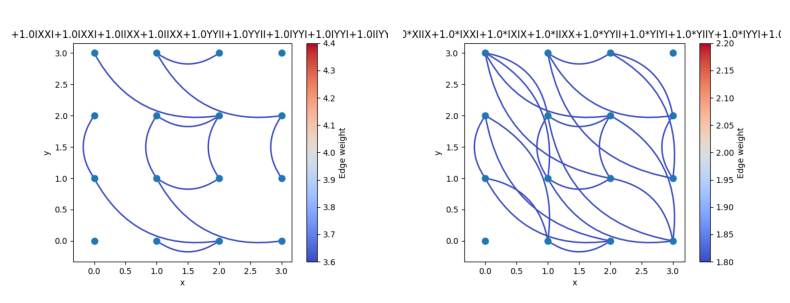

In [7]:
n = 2
D = 2

'''
pauli_strings = []
for k in range(D*n):
    pauli_strings.append(single_pauli(D*n, k))
pauli_strings.append(sum_single_paulis(D*n))
'''

'''
pauli_strings = []
for i in range(D*n):
    for j in range(i+1, D*n):
        if i != j:
            pauli_strings.append(double_pauli(D*n, i, j, "X", "X"))
pauli_strings.append(sum_NN_pair_paulis(D*n, "X", "X"))
pauli_strings.append(sum_pair_paulis(D*n, "X", "X"))
'''

pauli_strings = []
pauli_strings.append(sum_NN_pair_paulis(D*n, "X", "X") + sum_NN_pair_paulis(D*n, "Y", "Y"))
pauli_strings.append(sum_pair_paulis(D*n, "X", "X") + sum_pair_paulis(D*n, "Y", "Y"))

figs = []
if D == 2:
    Lx, Ly = 2**n, 2**n
    N = Lx * Ly
    for paulis in pauli_strings:
        adj = abs(sum_of_paulis(paulis))
        coords = map_nodes_to_lattice(adj, (Lx, Ly))  # {node: (row, col)}
        fig, _ = plot_lattice_graph_weighted_curved(adj, (Lx, Ly), title="+".join(paulis))
        figs.append(fig)
elif D == 3:
    Lx, Ly, Lz = 2**n, 2**n, 2**n
    N = Lx * Ly * Lz
    for paulis in pauli_strings:
        adj = abs(sum_of_paulis(paulis))
        coords = map_nodes_to_lattice(adj, (Lx, Ly, Lz))  # {node: (row, col)}
        fig, _ = plot_lattice_graph_weighted_curved(adj, (Lx, Ly, Lz), title="+".join(paulis))
        figs.append(fig)
        
compose_figs_grid(figs, 2)

# Plot colored edges

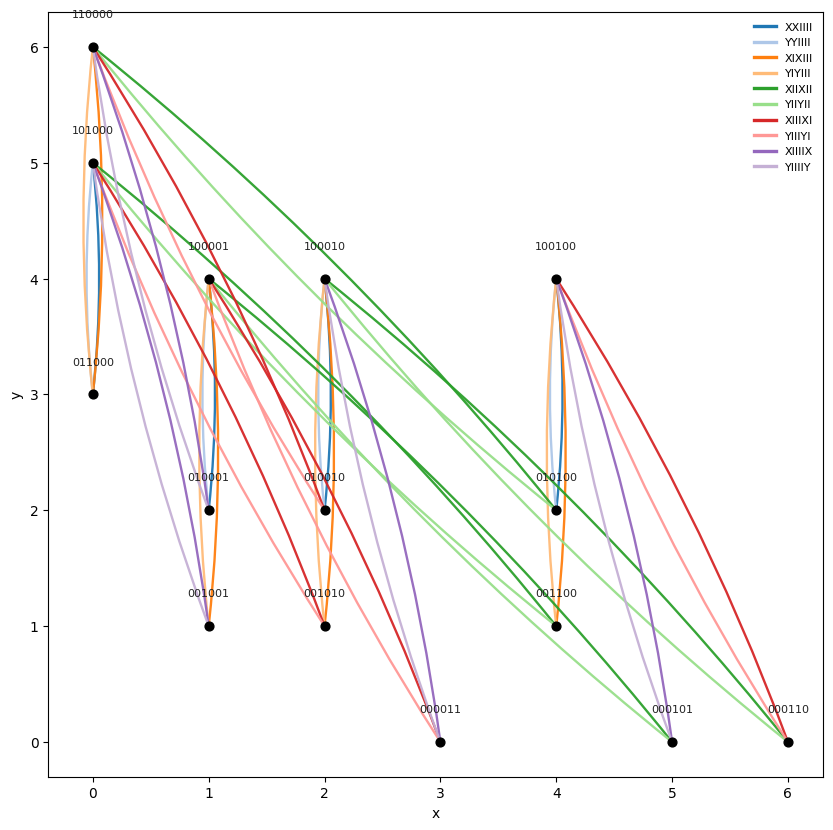

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.lines import Line2D
from typing import Iterable, Tuple, Dict, List, Optional, Callable

# --------- small utils ---------
def _popcount(x: int) -> int:
    c = 0
    while x:
        x &= x - 1
        c += 1
    return c

def map_nodes_to_lattice(N: int, dims: Iterable[int]) -> Dict[int, Tuple[int, ...]]:
    dims = tuple(int(x) for x in dims)
    if np.prod(dims) != N:
        raise ValueError(f"prod(dims)={np.prod(dims)} must equal N={N}")
    return {k: tuple(np.unravel_index(k, dims, order="C")) for k in range(N)}

def _bezier2d_patch(p0, p1, bend: float, sign: int = 1, **patch_kwargs):
    x0, y0 = p0; x1, y1 = p1
    mx, my = (x0+x1)/2.0, (y0+y1)/2.0
    dx, dy = x1 - x0, y1 - y0
    L = (dx*dx + dy*dy) ** 0.5
    cx, cy = (mx, my) if L == 0 else (mx + sign*bend*L*(-dy/L), my + sign*bend*L*(dx/L))
    path = Path([(x0,y0),(cx,cy),(x1,y1)], [Path.MOVETO, Path.CURVE3, Path.CURVE3])
    return PathPatch(path, fill=False, **patch_kwargs)

def _bezier3d_samples(p0, p1, bend: float, sign: int = 1, n: int = 120):
    p0 = np.asarray(p0, float); p1 = np.asarray(p1, float)
    v  = p1 - p0; L = np.linalg.norm(v)
    if L == 0:
        return np.full(n, p0[0]), np.full(n, p0[1]), np.full(n, p0[2])
    d  = v / L
    up = np.array([0.0, 0.0, 1.0])
    if abs(np.dot(d, up)) > 0.9: up = np.array([0.0, 1.0, 0.0])
    nvec = np.cross(d, up); nlen = np.linalg.norm(nvec)
    nvec = nvec / (nlen if nlen else 1.0)
    m  = (p0 + p1) * 0.5
    c  = m + sign * bend * L * nvec
    t  = np.linspace(0,1,n); u = 1 - t
    B  = (u*u)[:,None]*p0 + (2*u*t)[:,None]*c + (t*t)[:,None]*p1
    return B[:,0], B[:,1], B[:,2]

def _bitstring(u: int, n: int, order: str = "msb") -> str:
    """
    Bitstring for integer u with length n.
    order='msb' prints MSB→LSB (left to right), matching Pauli string order.
    """
    s = format(u, f"0{n}b")
    return s if order == "msb" else s[::-1]

def hamming_weight_equals(k: int) -> Callable[[int], bool]:
    """Keep nodes whose bitstring has exactly k ones."""
    return lambda u: _popcount(u) == k

# --------- Pauli action (LEFT char ↔ MSB) ---------
def _flip_parity_from_pstring(pstr: str):
    """
    Conforms to: leftmost Pauli char acts on MSB (bit index n-1).
    For P|u> = i^{nY} * (-1)^{popcount(u & parity)} |u XOR flip|.
    Returns (flip_mask, nY, parity_mask).
    """
    n = len(pstr)
    flip = 0; nY = 0; parity = 0
    for j, P in enumerate(pstr):
        bit = n - 1 - j               # <<---- MSB-aligned mapping
        if P == 'X':
            flip |= (1 << bit)
        elif P == 'Y':
            flip |= (1 << bit); nY += 1; parity |= (1 << bit)
        elif P == 'Z':
            parity |= (1 << bit)
        elif P != 'I':
            raise ValueError("Pauli string must contain only I,X,Y,Z")
    return flip, nY, parity

# --------- main (UNDIRECTED, with cancellation, labels, filter, ordered legend) ---------
def plot_operator_adjacency_by_pauli_terms(
    pauli_terms: List[Tuple[complex, str]],
    dims: Optional[Iterable[int]] = None,   # lattice for 2^n nodes; default ~square 2D
    node_size: float = 40.0,
    bend: float = 0.32,
    linewidth: float = 1.7,
    width_by_ampl: bool = True,
    cancel_tol: float = 1e-12,              # omit pairs whose net off-diagonal ~ 0
    max_terms_in_legend: int = 40,
    n_samples_3d: int = 120,
    title: Optional[str] = None,
    figsize: Optional[Tuple[float,float]] = None,
    show: bool = False,
    close_on_return: bool = True,
    # labels
    label_nodes: bool = True,
    bit_order: str = "msb",                 # keep as 'msb' to match Pauli order
    label_fontsize: int = 8,
    label_color: str = "#222",
    label_offset_2d: Tuple[float, float] = (0.0, 0.28),
    label_offset_3d: Tuple[float, float, float] = (0.0, 0.0, 0.15),
    # node filter
    include_node: Optional[Callable[[int], bool]] = None,
):
    """
    Interpret H = Σ_k c_k P_k (size 2^n × 2^n) as an undirected graph on computational
    basis states. Each Pauli string gets its own color; multiple strings on the same
    pair (u,v) draw multiple curved arcs. Pairs whose net off-diagonal cancels are hidden.

    Conventions:
      - LEFTMOST Pauli char acts on LEFTMOST displayed bit (MSB).
      - Node labels show bitstrings MSB→LSB to match Pauli order.
    """
    if not pauli_terms:
        raise ValueError("Empty pauli_terms")
    n = len(pauli_terms[0][1])
    if any(len(p) != n for _, p in pauli_terms):
        raise ValueError("All Pauli strings must have equal length")
    N = 1 << n

    # default near-square 2D layout
    if dims is None:
        a = 1 << (n//2); b = 1 << (n - n//2)
        dims = (a, b)
    dims = tuple(int(x) for x in dims)
    if len(dims) not in (2,3): raise NotImplementedError("Only D=2 or D=3 supported")

    layout = map_nodes_to_lattice(N, dims)

    # visible nodes set
    visible = set(range(N)) if include_node is None else {u for u in range(N) if include_node(u)}

    # ---- Legend/color order matches input order (first occurrence wins) ----
    labels_in_input = [p for _, p in pauli_terms]
    label_to_index: Dict[str, int] = {}
    label_order: List[str] = []
    for lab in labels_in_input:
        if lab not in label_to_index:
            label_to_index[lab] = len(label_order)
            label_order.append(lab)
    tab = plt.get_cmap('tab20')
    def color_for(lab: str):
        idx = label_to_index[lab]
        return tab((idx % 20) / 19.0)

    # Aggregate complex amplitudes per unordered pair and per label
    pair_net:  Dict[Tuple[int,int], complex] = {}
    pair_term: Dict[Tuple[int,int], Dict[str, complex]] = {}

    for c, pstr in pauli_terms:
        flip, nY, parity = _flip_parity_from_pstring(pstr)   # <<— MSB-aligned
        if flip == 0:
            continue  # diagonal-only; no off-diagonal edge
        phaseY = (1j) ** nY
        for u in range(N):
            v = u ^ flip
            if u >= v:
                continue  # undirected pair once
            phase_par = -1 if (_popcount(u & parity) & 1) else 1
            amp = c * phaseY * phase_par
            pair_net[(u,v)] = pair_net.get((u,v), 0.0) + amp
            d = pair_term.setdefault((u,v), {})
            d[pstr] = d.get(pstr, 0.0) + amp

    # Survivors after cancellation & node visibility
    survivors_all = {pair: tm for pair, tm in pair_term.items()
                     if abs(pair_net.get(pair, 0.0)) > cancel_tol}
    survivors = { (u,v): tm for (u,v), tm in survivors_all.items()
                  if (u in visible and v in visible) }

    # scaling for line width
    all_ampl = [abs(z) for tm in survivors.values() for z in tm.values()]
    max_ampl = max(all_ampl) if all_ampl else 1.0

    # --------- draw ---------
    if len(dims) == 2:
        xs = [layout[k][1] for k in range(N)]
        ys = [layout[k][0] for k in range(N)]
        fig, ax = plt.subplots(figsize=figsize)

        for (u, v), termmap in survivors.items():
            # Overlap arcs ordered by input order of labels
            items = sorted(termmap.items(), key=lambda kv: label_to_index[kv[0]])
            k = len(items)
            offsets = np.arange(k) - (k - 1)/2.0
            p0 = (xs[u], ys[u]); p1 = (xs[v], ys[v])
            for t_off, (lab, amp) in zip(offsets, items):
                sign = 1 if t_off >= 0 else -1
                bend_mag = bend * (1.0 + 0.18*abs(t_off))
                color = color_for(lab)
                lw = linewidth * (0.5 + 0.5 * (abs(amp)/max_ampl)) if width_by_ampl else linewidth
                patch = _bezier2d_patch(p0, p1, bend=bend_mag, sign=sign,
                                        edgecolor=color, linewidth=lw, zorder=1, alpha=0.95)
                try: patch.set_capstyle("round")
                except Exception: pass
                ax.add_patch(patch)

        # nodes (only visible)
        ax.scatter([xs[u] for u in visible], [ys[u] for u in visible],
                   s=node_size, c="#000000", zorder=3)

        # node labels (MSB→LSB to match Pauli)
        if label_nodes:
            dx, dy = label_offset_2d
            for u in visible:
                ax.text(xs[u]+dx, ys[u]+dy,
                        _bitstring(u, n, order=bit_order),
                        fontsize=label_fontsize, color=label_color,
                        ha="center", va="center", zorder=4)

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x"); ax.set_ylabel("y")
        if title: ax.set_title(title)

        # Legend in input order
        present_set = {lab for tm in survivors.values() for lab in tm.keys()}
        present = [lab for lab in label_order if lab in present_set]
        if present and len(present) <= max_terms_in_legend:
            handles = [Line2D([0],[0], color=color_for(l), lw=2.4, label=l) for l in present]
            ax.legend(handles=handles, frameon=False, loc="upper right", fontsize=8)

        if show: plt.show()
        elif close_on_return:
            fig.canvas.draw_idle(); plt.close(fig)
        return fig, ax

    else:  # 3D
        from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111, projection="3d")

        xs = [layout[k][2] for k in range(N)]
        ys = [layout[k][1] for k in range(N)]
        zs = [layout[k][0] for k in range(N)]

        for (u, v), termmap in survivors.items():
            items = sorted(termmap.items(), key=lambda kv: label_to_index[kv[0]])
            k = len(items)
            offsets = np.arange(k) - (k - 1)/2.0
            p0 = (xs[u], ys[u], zs[u]); p1 = (xs[v], ys[v], zs[v])
            for t_off, (lab, amp) in zip(offsets, items):
                sign = 1 if t_off >= 0 else -1
                bend_mag = bend * (1.0 + 0.18*abs(t_off))
                X, Y, Z = _bezier3d_samples(p0, p1, bend=bend_mag, sign=sign, n=n_samples_3d)
                lw = linewidth * (0.5 + 0.5 * (abs(amp)/max_ampl)) if width_by_ampl else linewidth
                ax.plot(X, Y, Z, color=color_for(lab), linewidth=lw, zorder=1, alpha=0.95)

        ax.scatter([xs[u] for u in visible], [ys[u] for u in visible], [zs[u] for u in visible],
                   s=node_size, c="#000000", zorder=3)

        if label_nodes:
            dx, dy, dz = label_offset_3d
            for u in visible:
                ax.text(xs[u]+dx, ys[u]+dy, zs[u]+dz,
                        _bitstring(u, n, order=bit_order),
                        fontsize=label_fontsize, color=label_color,
                        ha="center", va="center", zorder=4)

        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
        if title: ax.set_title(title)

        present_set = {lab for tm in survivors.values() for lab in tm.keys()}
        present = [lab for lab in label_order if lab in present_set]
        if present and len(present) <= max_terms_in_legend:
            handles = [Line2D([0],[0], color=color_for(l), lw=2.4, label=l) for l in present]
            ax.legend(handles=handles, frameon=False, loc="upper left", fontsize=8)

        if show: plt.show()
        elif close_on_return:
            fig.canvas.draw_idle(); plt.close(fig)
        return fig, ax

pauli_terms = [(1.0, "XXIIII"),
               (1.0, "YYIIII"),
               (1.0, "XIXIII"),
               (1.0, "YIYIII"),
               (1.0, "XIIXII"),
               (1.0, "YIIYII"),
               (1.0, "XIIIXI"),
               (1.0, "YIIIYI"),
               (1.0, "XIIIIX"),
               (1.0, "YIIIIY"),
               ]

fig, ax = plot_operator_adjacency_by_pauli_terms(
    pauli_terms,
    dims=(8,8),
    title="",
    label_nodes=True,          # show bitstrings MSB→LSB to match Pauli order
    bit_order="msb",
    bend=0.05,
    width_by_ampl=True,
    show=True,
    figsize=(10, 10),
    include_node=hamming_weight_equals(2)
)